In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, mean_squared_error, silhouette_score
from sklearn.metrics import confusion_matrix

In [20]:
df = pd.read_csv('/content/WineQT.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [21]:
null_counts = df.isnull().sum()
print("\nMissing Values per Column:")
print(null_counts)


Missing Values per Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [22]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicates}")


Number of duplicate rows found: 0


In [23]:
df['is_good'] = (df['quality'] >= 7).astype(int)

In [24]:
X_class = df.drop(['quality', 'is_good'], axis=1)
y_class = df['is_good']

In [25]:
X_reg = df.drop(['alcohol', 'quality', 'is_good'], axis=1)
y_reg = df['alcohol']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

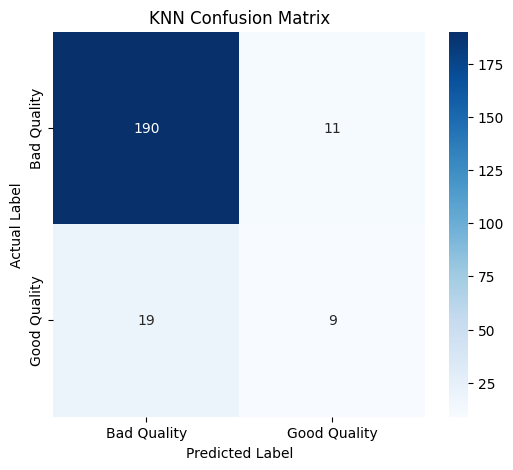

In [37]:
cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Bad Quality', 'Good Quality'],
            yticklabels=['Bad Quality', 'Good Quality'])

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [29]:
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

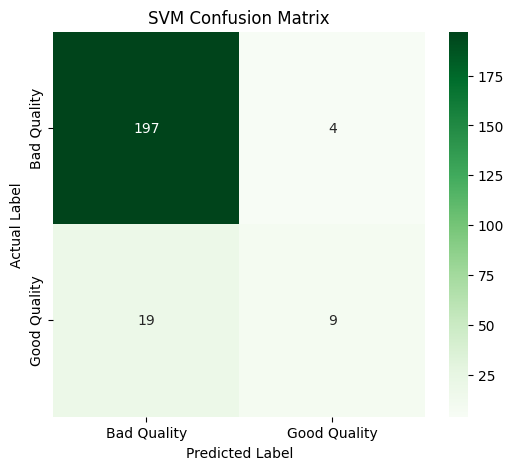

In [39]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens",
            xticklabels=['Bad Quality', 'Good Quality'],
            yticklabels=['Bad Quality', 'Good Quality'])

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [30]:
lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)
reg_pred = lin_reg.predict(Xr_test)

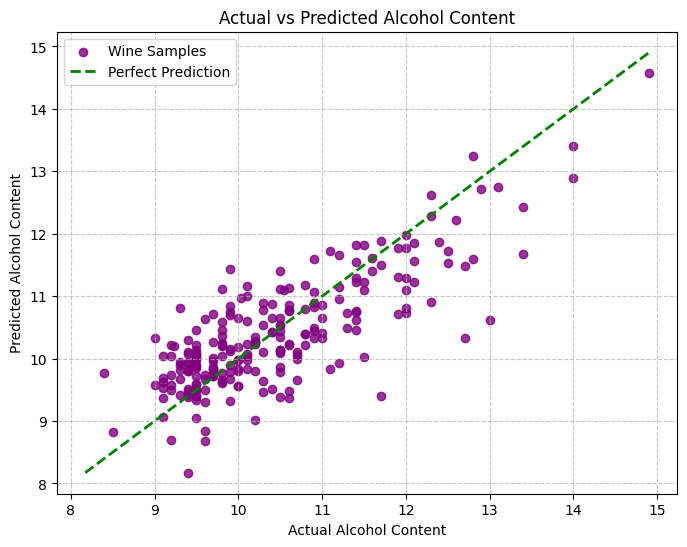

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(yr_test, reg_pred, alpha=0.8, c="purple", label='Wine Samples')

plt.xlabel("Actual Alcohol Content")
plt.ylabel("Predicted Alcohol Content")
plt.title("Actual vs Predicted Alcohol Content")
plt.grid(True, linestyle='--', alpha=0.7)

min_val = min(yr_test.min(), reg_pred.min())
max_val = max(yr_test.max(), reg_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'g--', linewidth=2, label='Perfect Prediction')

plt.legend()
plt.show()

In [31]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)
clusters = kmeans.predict(X_test_scaled)

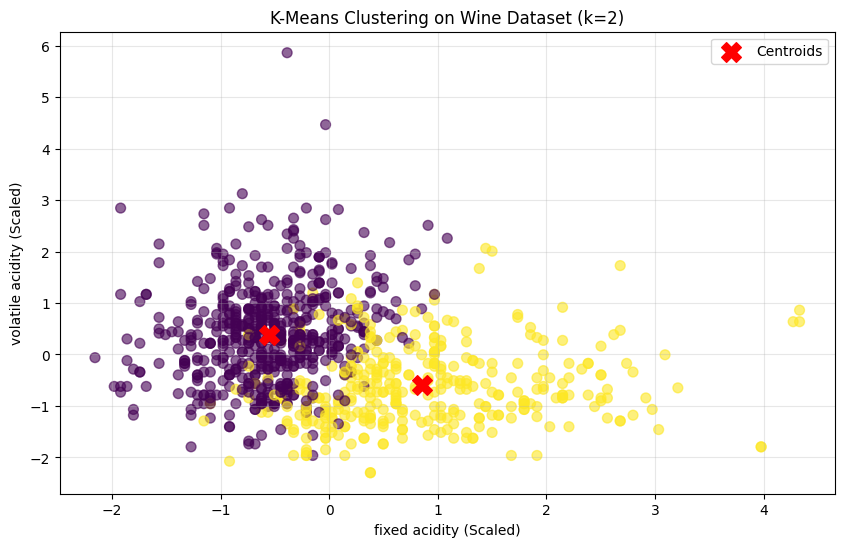

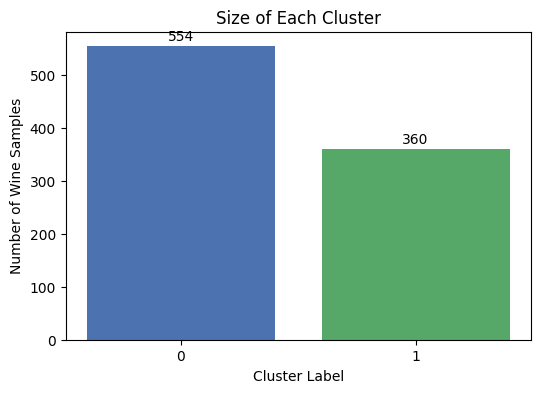

In [41]:
plt.figure(figsize=(10, 6))

plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
            c=kmeans.labels_, s=50, cmap='viridis', alpha=0.6)

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200,
            label='Centroids')

plt.xlabel(X_class.columns[0] + " (Scaled)")
plt.ylabel(X_class.columns[1] + " (Scaled)")
plt.title("K-Means Clustering on Wine Dataset (k=2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cluster_sizes = pd.Series(kmeans.labels_).value_counts().sort_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=['#4c72b0', '#55a868'])
plt.xlabel('Cluster Label')
plt.ylabel('Number of Wine Samples')
plt.title('Size of Each Cluster')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.show()

In [32]:
print(f"KNN Accuracy: {accuracy_score(y_test, knn_pred):.2f}")
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.2f}")
print(f"Regression MSE: {mean_squared_error(yr_test, reg_pred):.2f}")
print(f"K-Means Silhouette: {silhouette_score(X_test_scaled, clusters):.2f}")

KNN Accuracy: 0.87
SVM Accuracy: 0.90
Regression MSE: 0.45
K-Means Silhouette: 0.21


In [33]:
#KNN	Supervised	type is Accuracy, High performance because the dataset has clear geometric clusters. KNN relies on physical proximity
#SVM	Supervised	type is Accuracy,	Often outperforms KNN by finding the "Optimal Hyperplane." It is robust against outliers
#Linear Regression type is Supervised,	MSE	Used for predicting continuous values. Performance depends on how linear the relationship between features is
#K-Means	Unsupervised	type is Silhouette,	Used to find hidden patterns. On Iris, it usually recreates the 3 species groups fairly well without labels